# Exploratory Data Analysis: MovieLens 100k

## 1. The Concept of Link Prediction in RecSys
In a modern recommender system, we don't just see a table of users and ratings. Instead, we view the system as a **Bipartite Graph**:
- **Nodes Set A:** Users
- **Nodes Set B:** Movies
- **Edges:** A link exists if a user has interacted with a movie.

**Link Prediction** is the task of predicting the likelihood of a future edge forming between a user node and a movie node. If our model predicts a high probability for a non-existent link, that becomes our **Recommendation**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline
sns.set(style='whitegrid')

# Load the datasets
ratings_cols = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings = pd.read_csv('data/u.data', sep='\t', names=ratings_cols)

items_cols = ['movie_id', 'title', 'release_date', 'video_release_date', 'imdb_url'] + [f'genre_{i}' for i in range(19)]
items = pd.read_csv('data/u.item', sep='|', names=items_cols, encoding='latin-1')

users_cols = ['user_id', 'age', 'gender', 'occupation', 'zip_code']
users = pd.read_csv('data/u.user', sep='|', names=users_cols)

print(f"Loaded {len(ratings)} ratings, {len(items)} movies, and {len(users)} users.")

Loaded 100000 ratings, 1682 movies, and 943 users.


## 2. Graph Sparsity: The 'Missing Link' Challenge
Sparsity tells us how many of the possible connections in our graph actually exist. In a fully connected graph, every user would have rated every movie.

In reality, users only watch a tiny fraction of available content. High sparsity is the reason we need Link Prediction: we need to find the 'hidden' gems among the millions of missing links.

In [2]:
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_ratings = len(ratings)
possible_links = n_users * n_movies
sparsity = 1 - (n_ratings / possible_links)

print(f"Number of Users (Nodes A): {n_users}")
number_of_movies = n_movies
print(f"Number of Movies (Nodes B): {n_movies}")
print(f"Total Possible Links: {possible_links:,}")
print(f"Actual Links (Edges): {n_ratings:,}")
print(f"Graph Sparsity: {sparsity:.4f} ({sparsity*100:.2f}% of links are missing)")

Number of Users (Nodes A): 943
Number of Movies (Nodes B): 1682
Total Possible Links: 1,586,126
Actual Links (Edges): 100,000
Graph Sparsity: 0.9370 (93.70% of links are missing)


## 3. Rating Distribution: Defining a 'Positive Link'
Link prediction algorithms usually work better on binary data (Link exists vs. Doesn't exist). 
However, a rating of '1' or '2' might mean the user disliked the movie. In a graph-based RecSys, we often only want to predict **positive links** (e.g., ratings 4 and 5) to ensure our recommendations are high quality.

C:\Users\RoG\AppData\Local\Temp\ipykernel_33248\2034300865.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='magma')


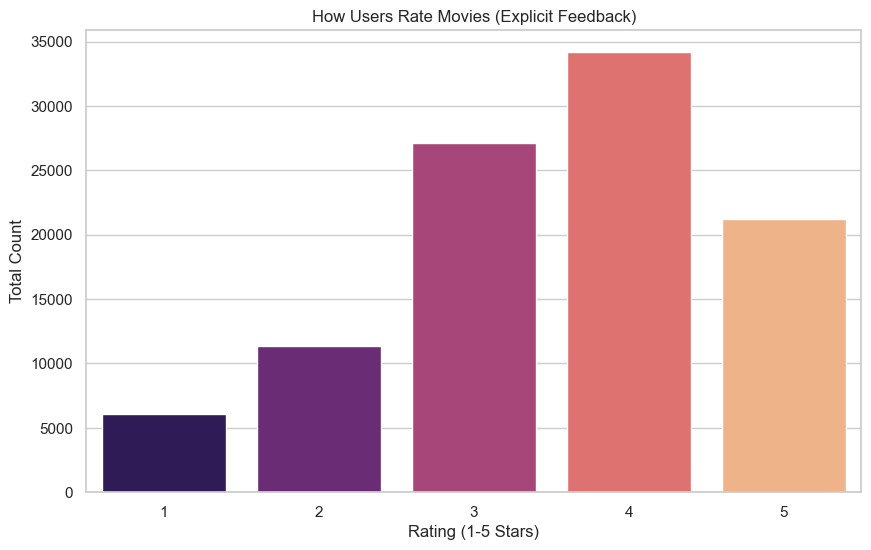

Positive Links (Rating >= 4): 55375 (55.38% of total)


In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(x='rating', data=ratings, palette='magma')
plt.title('How Users Rate Movies (Explicit Feedback)')
plt.xlabel('Rating (1-5 Stars)')
plt.ylabel('Total Count')
plt.show()

positive_links_count = len(ratings[ratings['rating'] >= 4])
print(f"Positive Links (Rating >= 4): {positive_links_count} ({positive_links_count/len(ratings)*100:.2f}% of total)")

## 4. Node Degree Distribution: Power Users vs. Casual Watchers
In network science, the 'Degree' of a node is the number of connections it has.
- **High Degree Users:** 'Power users' who provide a lot of data for the model.
- **Low Degree Users:** The 'Cold Start' problem. It's much harder to predict links for a user with only 20 ratings.

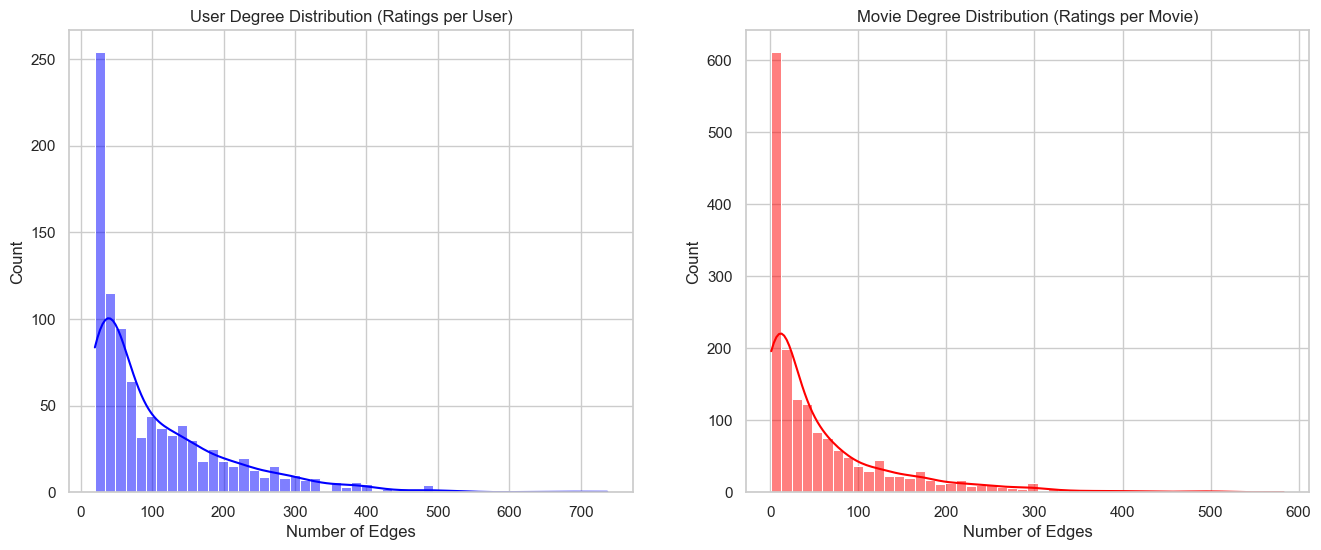

In [4]:
user_counts = ratings.groupby('user_id').size()
movie_counts = ratings.groupby('movie_id').size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(user_counts, bins=50, ax=ax1, kde=True, color='blue')
ax1.set_title('User Degree Distribution (Ratings per User)')
ax1.set_xlabel('Number of Edges')

sns.histplot(movie_counts, bins=50, ax=ax2, kde=True, color='red')
ax2.set_title('Movie Degree Distribution (Ratings per Movie)')
ax2.set_xlabel('Number of Edges')

plt.show()

## 5. Popularity Bias
The most popular movies (high degree nodes) are often recommended to everyone. While they are safe bets, a good Link Prediction model should also find 'niche' links in the long tail.

In [5]:
popular_movies = movie_counts[movie_counts > 100].index
top_movies = ratings[ratings['movie_id'].isin(popular_movies)].groupby('movie_id')['rating'].mean().sort_values(ascending=False).head(10)

print("Top 10 Highly Rated Movies (Min 100 ratings):")
for mid, rating in top_movies.items():
    title = items[items['movie_id'] == mid]['title'].values[0]
    print(f"- {title}: {rating:.2f} stars")

Top 10 Highly Rated Movies (Min 100 ratings):
- Close Shave, A (1995): 4.49 stars
- Schindler's List (1993): 4.47 stars
- Wrong Trousers, The (1993): 4.47 stars
- Casablanca (1942): 4.46 stars
- Shawshank Redemption, The (1994): 4.45 stars
- Rear Window (1954): 4.39 stars
- Usual Suspects, The (1995): 4.39 stars
- Star Wars (1977): 4.36 stars
- 12 Angry Men (1957): 4.34 stars
- Citizen Kane (1941): 4.29 stars
